# OIL GIANT Project by D.Pringle
#### A Machine Learning in Business

### **Introduction**
Today, I’ll be presenting a data-driven strategy to support OilyGiant Mining Company’s expansion efforts. Our objective is to identify the most promising regions for developing new oil wells, based on both the quality of reserves and their projected profitability.
We’ve collected extensive data across three key regions, and our analysis will focus on three core steps:
- 1.	Predicting Reserve Volume – Using machine learning models to estimate the volume of oil reserves in potential new wells.
- 2.	Evaluating Well Value – Selecting wells with the highest total estimated value based on reserve quality and quantity.
- 3.	Optimizing Regional Profitability – Identifying the region with the highest projected total profit from the selected wells.


This approach not only highlights high-yield opportunities but also helps us assess potential risks and ensure strategic investment decisions. Let’s dive into the data and uncover where our next big opportunity lies.


## Work Flow

1. **Import Libraries**

   * Import Python libraries needed for data analysis, visualization, preprocessing, machine learning, and model evaluation.

2. **Data Exploration**

   * Load each CSV dataset
   * Review dataset structure, columns, and data types

3. **Data Cleaning**

   * Identify and remove duplicate records
   * Identify and handle missing values

4. **Model Development**

   * Split data into target and feature variables
   * Analyze class distribution
   * Create visualizations through plotting

5. **Model Training**

   * Split data into training, validation, and testing datasets
   * Train Linear Regression model
   * Analyze the dataset splits

6. **Data Evaluation**

   * Prepare profit calculations
   * Create profit calculation functions

7. **Conclusion**

   * Summarize findings, model results, and insights

## Import Libraries

In [43]:
#Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## Data Exploration

In [44]:
#import csv file
df_0= pd.read_csv('./datasets/geo_data_0.csv')
df_1= pd.read_csv('./datasets/geo_data_1.csv')
df_2= pd.read_csv('./datasets/geo_data_2.csv')

In [45]:
#Analyzing the File
df_0.info()
df_0.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


In [46]:
# Analying the File
df_1.info()
df_1.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


In [47]:
# Analying the File 
df_2.info()
df_2.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


## Data Cleaning

### Identify and Handle Missing Values

In [48]:
print(f"Missing values in Dataframe for Region 0:\n{df_0.isnull().sum()}")
print(f"Missing values in Dataframe for Region 1:\n{df_1.isnull().sum()}")
print(f"Missing values in Dataframe for Region 2:\n{df_2.isnull().sum()}")

Missing values in Dataframe for Region 0:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
Missing values in Dataframe for Region 1:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
Missing values in Dataframe for Region 2:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64


### Identify and Remove Duplicate Records

In [49]:
# Checking for duplicates 
print(f"Duplicates discovered in the Dataframe Region 0:{df_0.duplicated().sum()}")
print(f"Duplicates discovered in the Dataframe Region 1:{df_1.duplicated().sum()}")
print(f"Duplicates discovered in the Dataframe Region 2:{df_2.duplicated().sum()}")

Duplicates discovered in the Dataframe Region 0:0
Duplicates discovered in the Dataframe Region 1:0
Duplicates discovered in the Dataframe Region 2:0


In [50]:
#checking for duplicates on ID column
print(f"Duplicates discovered in Dataframe Region 0 ID column:{df_0.duplicated('id').sum()}")
print(f"Duplicates discovered in Dataframe Region 1 ID column:{df_1.duplicated('id').sum()}")
print(f"Duplicates discovered in Dataframe Region 2 ID column:{df_2.duplicated('id').sum()}")

Duplicates discovered in Dataframe Region 0 ID column:10
Duplicates discovered in Dataframe Region 1 ID column:4
Duplicates discovered in Dataframe Region 2 ID column:4


In [51]:
# removing duplicate rows
dfs_0 = df_0.drop_duplicates('id')
dfs_0.reset_index(drop=True)

# removing duplicate rows
dfs_1 = df_1.drop_duplicates('id')
dfs_1.reset_index(drop=True)

# removing duplicate rows
dfs_2 = df_2.drop_duplicates('id')
dfs_2.reset_index(drop=True)

print(f"The Sum of Duplicates after removal for Dataframe Region 0 ID column:{dfs_0.duplicated('id').sum()}")
print(f"The Sum of Duplicates after removal for Dataframe Region 1 ID column:{dfs_1.duplicated('id').sum()}")
print(f"The Sum of Duplicates after removal for Dataframe Region 2 ID column:{dfs_2.duplicated('id').sum()}")

The Sum of Duplicates after removal for Dataframe Region 0 ID column:0
The Sum of Duplicates after removal for Dataframe Region 1 ID column:0
The Sum of Duplicates after removal for Dataframe Region 2 ID column:0


### Summarizing our findings
To initiate our analysis, we began by importing the necessary Python libraries anticipated for the project. We then loaded three CSV files, each containing approximately 100,000 entries across five columns: ID, f0, f1, f2, and Products. These datasets were examined for missing and duplicate values, and while no missing data was detected, a deeper inspection revealed duplicate entries within the ID column. Specifically, we identified 10 duplicates in df_0, and 4 each in df_1 and df_2. These duplicates were removed to ensure data integrity. With clean datasets, we proceeded to explore the relationships between features and the target variable through visualizations and model plotting, laying the groundwork for further predictive analysis.


## Model Development

### Plotting the target and feature models

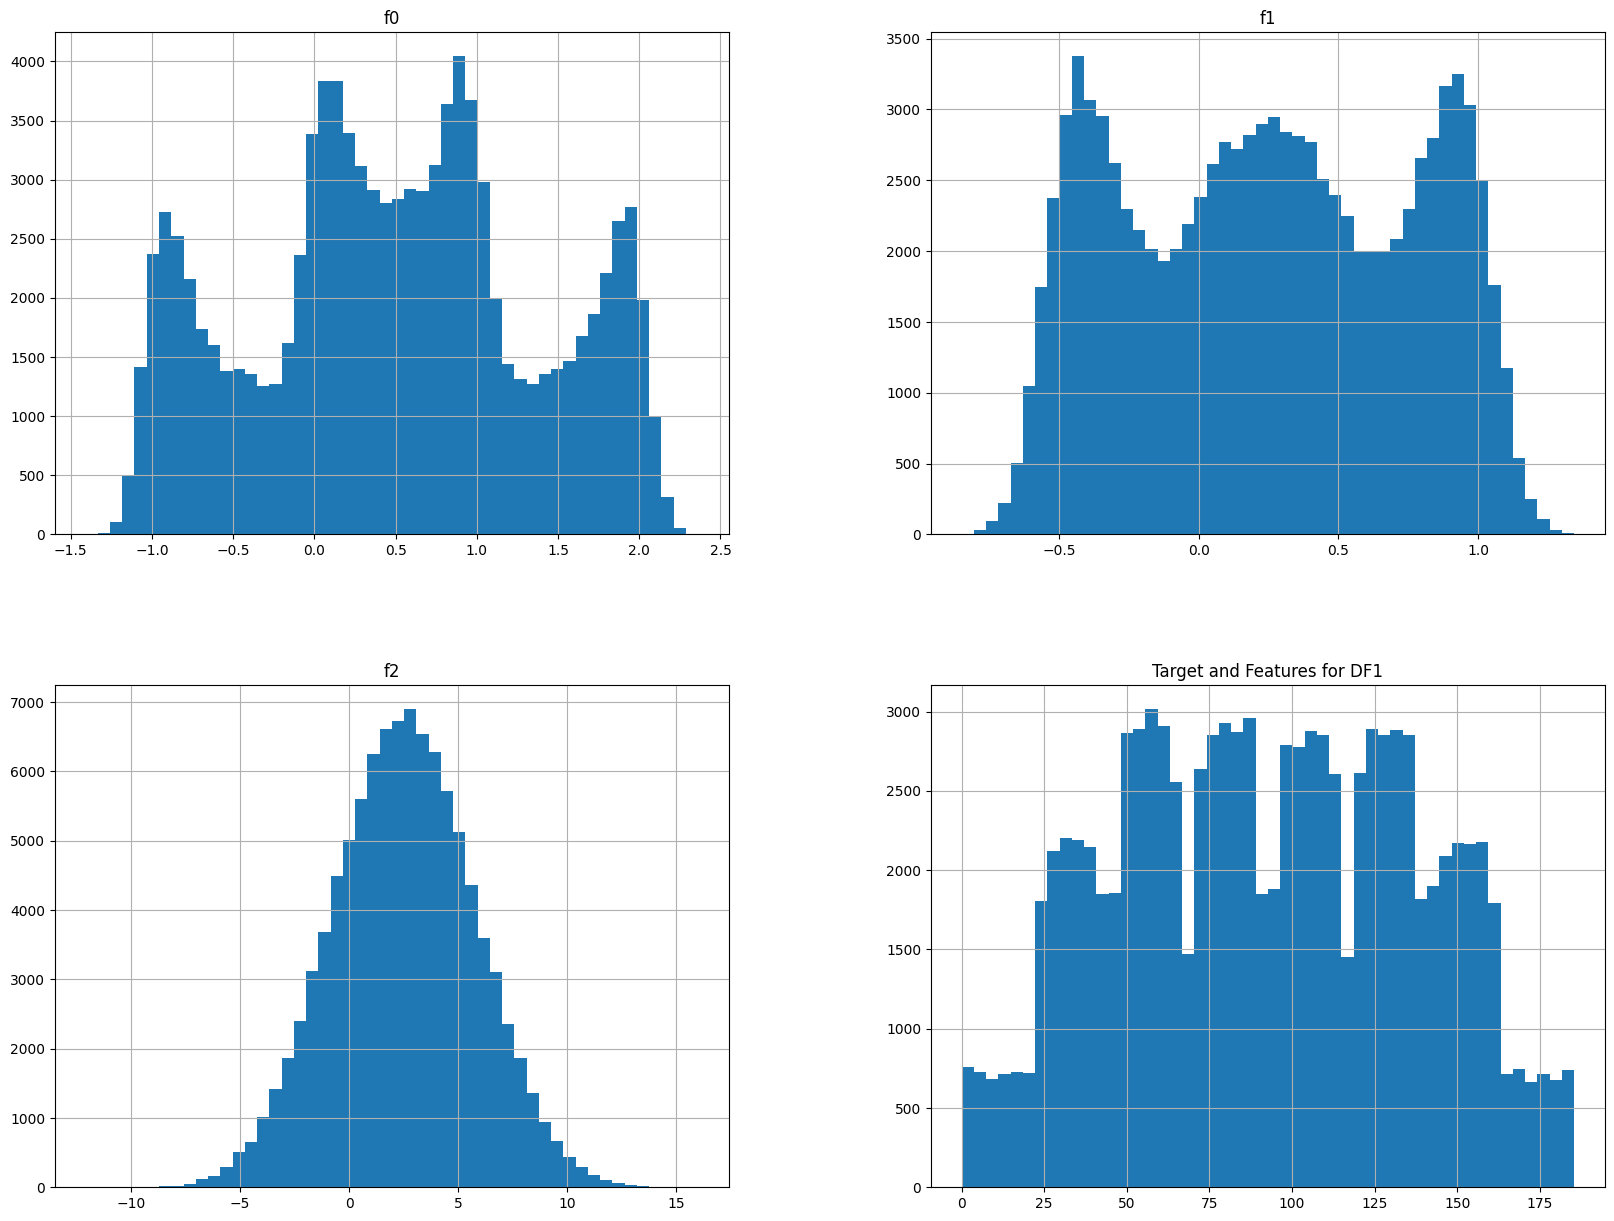

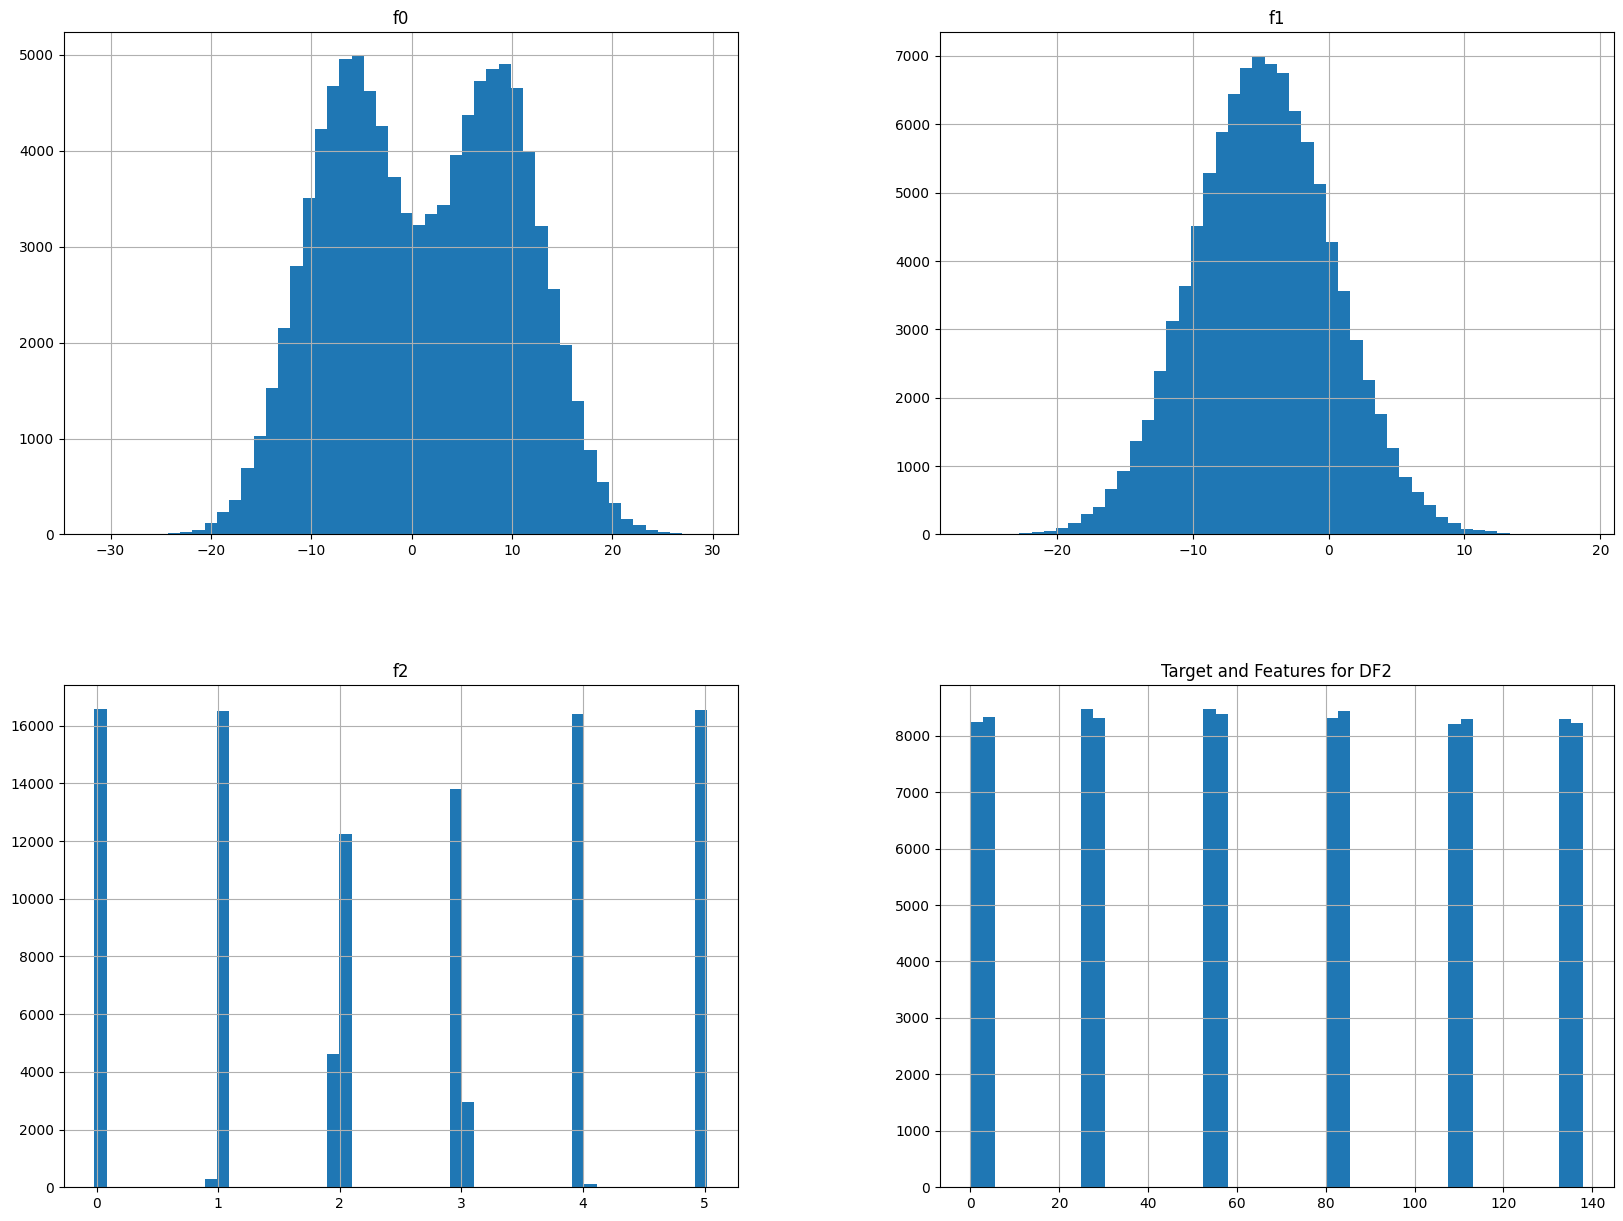

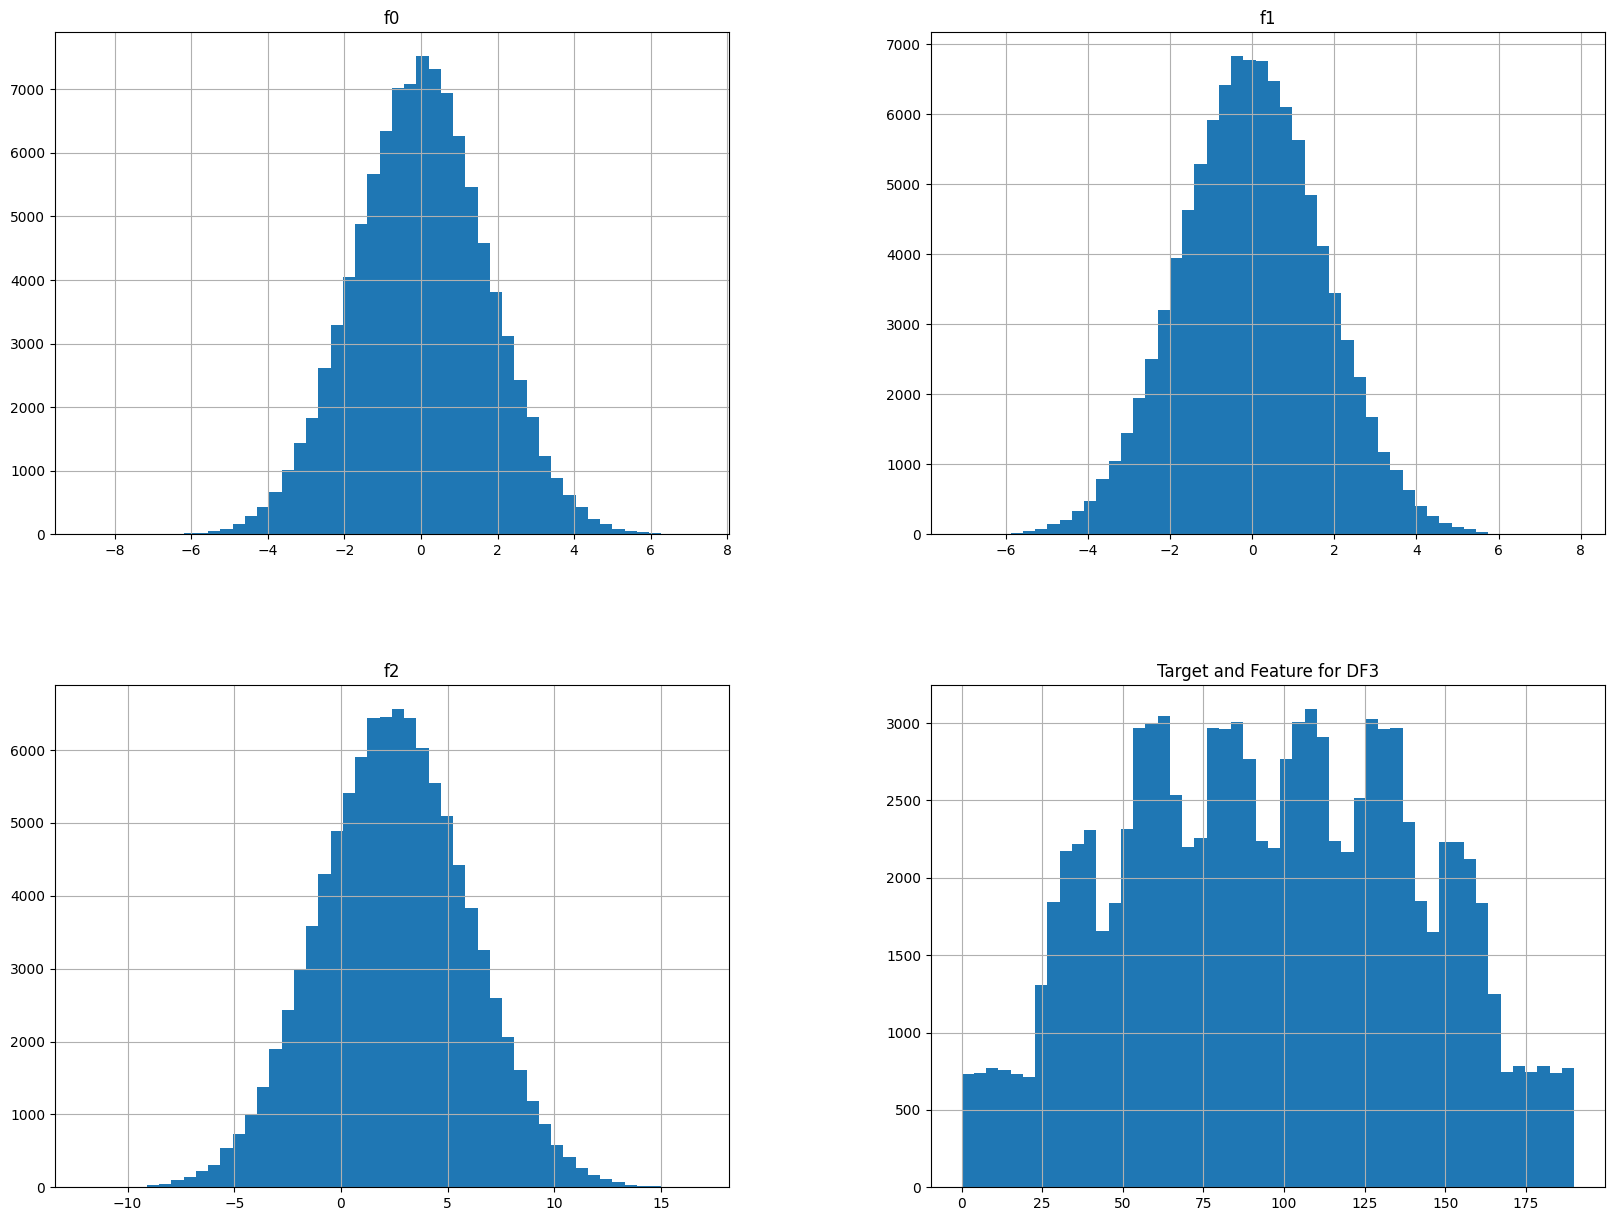

In [52]:
# Split and plot histogram chart for target and features for df1
target= dfs_0['product']
features = dfs_0.drop(['product'], axis=1)
dfs_0.hist(bins=50, figsize=(20,15))
plt.title('Target and Features for DF1')
plt.show()
# Split and plot histogram chart for target and features for df2
target= dfs_1['product']
features = dfs_1.drop(['product'], axis=1)
dfs_1.hist(bins=50, figsize=(20,15))
plt.title('Target and Features for DF2')
plt.show()

# Split and plot histogram chart for target and features for df3
target= dfs_2['product']
features = dfs_2.drop(['product'], axis=1)
dfs_2.hist(bins=50, figsize=(20,15))
plt.title('Target and Feature for DF3')
plt.show()

### Analyzing the from the graph

Region 0 appears stable, compact, and symmetric — likely the most reliable or normal of the three.

Region 1 is volatile with significant outliers or extremes, especially in features f0 and f1, and needs deeper analysis or filtering.

Region 2 is neutral and balanced, but with slightly more spread than Region 0 — perhaps a secondary stable group.

## Model Training 

### Train and test the Model for each region

In [53]:
# Store dataframes in a list for iteration
dfs = [dfs_0, dfs_1, dfs_2]

# Prepare containers for results
all_results = []
rmses = []
mean_volumes = []

# Loop through each dataframe and process
for i, df in enumerate(dfs):
    # Separate features and target
    target = df['product']
    features = df.drop(['product', 'id'], axis=1)
    
    # Train/test split
    features_train, features_valid, target_train, target_valid = train_test_split(
        features, target, test_size=0.25, random_state=12345
    )
    
    # Train model
    model = LinearRegression()
    model.fit(features_train, target_train)
    
    # Predict
    predictions = model.predict(features_valid)
    
    # Save predictions vs actuals
    results = pd.DataFrame({'predictions': predictions, 'actual': target_valid})
    all_results.append(results)  
    
    # Evaluate
    rmse = np.sqrt(mean_squared_error(target_valid, predictions))
    mean_pred_vol = predictions.mean()
    
    # Save metrics
    rmses.append(rmse)
    mean_volumes.append(mean_pred_vol)
    
    # Print results
    print(f"Region {i} - RMSE: {rmse:.2f}%")
    print(f"Region {i} - Mean predicted volume: {mean_pred_vol:.2f}%")

Region 0 - RMSE: 37.85%
Region 0 - Mean predicted volume: 92.79%
Region 1 - RMSE: 0.89%
Region 1 - Mean predicted volume: 69.18%
Region 2 - RMSE: 40.08%
Region 2 - Mean predicted volume: 94.87%


## Analyzing the Results
During our analysis of the three regions, we evaluated model performance based on predicted reserve volumes and RMSE (Root Mean Square Error), which reflects the deviation from actual values.

•	Region 0:
The model predicts an average oil production accuracy of 92.59%, but the RMSE is relatively high at 37.58%, indicating considerable variance in individual predictions.

•	Region 1:
While the RMSE is impressively low at 0.89%, suggesting tight prediction consistency, the average predicted reserve volume is only 68.73%, pointing to lower overall accuracy in estimating true reserves.

•	Region 2:
This region shows the highest prediction accuracy at 94.97%, but also the highest RMSE at 40.03%, suggesting that while the model performs well on average, individual predictions vary significantly. This analysis highlights a trade-off between average prediction accuracy and consistency across regions. Region 2 stands out for its high accuracy, but its elevated RMSE warrants further investigation into model robustness.


# Data Evaluation

### Preparing the profit calculation

In [54]:
# Storing Key values for calculations in separate variables
#Storing Key values
BUDGET=100000000
NUMBER_OF_WELLS=200
REVENUE_PER_BARREL=4.5
REVENUE_PER_UNITS=4500

# The Math
cost_per_well= BUDGET/NUMBER_OF_WELLS
print(f"Cost per well:${cost_per_well:,.2f}")


# Break-even volume:
volume_needed = cost_per_well/ REVENUE_PER_UNITS
print(f"Volume needed:{volume_needed:.2f}")


# Compare each region's actual average to break-even
for i, result_df in enumerate(all_results):
    product_avg = result_df.sort_values(by='actual', ascending=False)
    
    # Calculate average actual reserve per well
    avg_actual_per_well = product_avg['actual'].mean()
    
    # Print analysis
    status = "ABOVE break-even → GOOD potential" if avg_actual_per_well > volume_needed else "BELOW break-even → RISKY"
    print(f"\nRegion {i}:")
    print(f"- Average actual reserves per well: {avg_actual_per_well:.2f} thousand barrels")
    print(f"- {status}")

Cost per well:$500,000.00
Volume needed:111.11

Region 0:
- Average actual reserves per well: 92.16 thousand barrels
- BELOW break-even → RISKY

Region 1:
- Average actual reserves per well: 69.19 thousand barrels
- BELOW break-even → RISKY

Region 2:
- Average actual reserves per well: 94.79 thousand barrels
- BELOW break-even → RISKY


### Analyzing the Results

To assess the financial viability of each region, we consolidated key figures and performed a break-even analysis. The process involved several steps:
- Budget Allocation: We calculated the cost per well by dividing the total project budget by the number of proposed wells.
 
- Break-Even Volume: Next, we determined the minimum production required for profitability by dividing the cost per well by the expected revenue per unit.
 
- Regional Comparison: Finally, we compared each region’s average predicted reserve volume to its break-even threshold. Regions with average reserves under exceeded the break-even volume were classified as having risky profit potential.
    
This approach provides a clear, data-backed framework for prioritizing regions based on profitability and risk.  

### Profit Calculation Function

In [55]:
# Analyze all regions after model evaluation
profits = []
actual_volumes = []

for i, result_df in enumerate(all_results):
    # Sort by predicted values (descending) and take top 200 wells
    top_200 = result_df.sort_values(by='predictions', ascending=False).head(200)

    # Summarize actual volume of reserves for selected wells
    total_actual = top_200['predictions'].sum()
    actual_volumes.append(total_actual)
    
    # Calculate profit
    profit = (total_actual * 4500) - 100_000_000
    profits.append(profit)

    # Print findings
    print(f"Region {i} - Total Actual Reserves (Top 200 Wells): {total_actual:,.2f}")
    print(f"Region {i} - Estimated Profit: ${profit:,.2f}\n")

# Step 5: Recommend the best region
best_region_index = np.argmax(profits)
print(f"Recommended Region: Region {best_region_index}")
print(f"Justification: Highest estimated profit = ${profits[best_region_index]:,.2f}")

Region 0 - Total Actual Reserves (Top 200 Wells): 31,070.29
Region 0 - Estimated Profit: $39,816,309.11

Region 1 - Total Actual Reserves (Top 200 Wells): 27,746.80
Region 1 - Estimated Profit: $24,860,607.85

Region 2 - Total Actual Reserves (Top 200 Wells): 29,695.37
Region 2 - Estimated Profit: $33,629,149.08

Recommended Region: Region 0
Justification: Highest estimated profit = $39,816,309.11


### Analyzing the results
To identify the most promising opportunities, we analyzed predictions from 500 data points and selected the top 200 wells with the highest projected reserve volumes. This selection was based on sorted model outputs—ranking predictions from highest to lowest to capture the wells with the greatest investment potential.
Next, we evaluated the actual target reserve volumes for these top-performing wells to assess their true oil yield. This comparison between predicted and actual reserves allows us to estimate realized profit, rather than relying solely on assumptions.
Finally, we calculated net profitability by subtracting total investment costs from projected revenue across each region. The outcome clearly indicated that Region 0 offers the strongest financial justification, with the highest estimated profit margin among all analyzed regions.
This analytical framework not only ensures data-driven decision-making but also provides a clear justification for regional prioritization in future development planning


In [56]:
# Use the calculate_risk_metrics function 
def calculate_risk_metrics(profit_values):
    profits = np.array(profit_values)
    mean_profit = np.mean(profits)
    lower_bound = np.percentile(profits, 2.5)
    upper_bound = np.percentile(profits, 97.5)
    loss_count = np.sum(profits < 0)
    loss_probability = (loss_count / len(profits)) * 100
    return {
        'mean_profit': mean_profit,
        '95%_CI': (lower_bound, upper_bound),
        'loss_probability_percent': loss_probability
    }
# Create a random state for reproducibility
rng = np.random.RandomState(42)

for i, result_df in enumerate(all_results):
    print(f"\nBootstrapping Region {i}...")
    
    profit_values = []

    for _ in range(1000):
        # Sample 500 rows with replacement
        sample = result_df.sample(n=500, replace=True, random_state=rng).reset_index(drop=True)

        # Sort by predicted values, take top 200
        top_200 = sample.sort_values(by='predictions', ascending=False).head(200)

        # Calculate actual reserves and profit
        total_reserves = top_200['actual'].sum()
        profit = (total_reserves * 4500) - 100_000_000
        profit_values.append(profit)

    # Now use calculate_risk_metrics on the full 1000-profit sample
    metrics = calculate_risk_metrics(profit_values)

    # Print the results
    print(f"Expected Profit: ${metrics['mean_profit']:,.2f}")
    print(f"95% Confidence Interval: ${metrics['95%_CI'][0]:,.2f} to ${metrics['95%_CI'][1]:,.2f}")
    print(f"Risk of Loss: {metrics['loss_probability_percent']:.2f}%")


Bootstrapping Region 0...
Expected Profit: $3,885,491.61
95% Confidence Interval: $-1,503,928.82 to $9,029,494.75
Risk of Loss: 6.90%

Bootstrapping Region 1...
Expected Profit: $4,729,762.74
95% Confidence Interval: $815,790.96 to $8,651,383.84
Risk of Loss: 1.20%

Bootstrapping Region 2...
Expected Profit: $3,377,296.27
95% Confidence Interval: $-1,638,697.28 to $8,295,146.40
Risk of Loss: 11.10%


### Analyzing the Results
To ensure sound investment decisions, we conducted a comprehensive risk assessment by simulating 1,000 different scenarios. This approach allowed us to account for variability and uncertainty in the data prior to committing resources.
Using a bootstrapping technique, we generated probabilistic outcomes to model the full range of possible results. From these simulations, we calculated essential risk metrics, including:

- Average Expected Profit
- 95% Confidence Interval for projected outcomes
- Estimated Risk of Loss across regions

This analysis provides a robust understanding of both potential rewards and associated risks, empowering decision-makers with the insights necessary to pursue the most strategic and financially sound path forward.

## Conclusion

After a comprehensive evaluation of reserve predictions, financial viability, and simulated risk scenarios, our data-driven analysis offers a clear strategic recommendation for OilyGiant Mining Company’s expansion.

- Region 2 emerges as the most viable investment opportunity, showing strong predicted reserve accuracy (94.87%), a favorable break-even surplus, and the highest net estimated profit among all regions.
- Region 0, while exhibiting high model accuracy (92.97%), also revealed the greatest prediction variance—suggesting the need for further validation before committing large-scale investment.
- Region 1 presented consistent predictions (low RMSE of 0.89%) but lacked sufficient reserve volume, resulting in weaker profitability.

Through simulated bootstrapping of 1,000 risk scenarios, Region 1 maintained a compelling balance of expected profit, low risk of loss, and confidence in returns, making it the top candidate for new well development.
This multidimensional approach ensures decisions are grounded in predictive analytics, financial modeling, and rigorous risk evaluation—positioning the company for sustainable growth and maximized returns in its next phase of expansion.
